# CoraML Facial-Walk Experiment

Train the transformer on facial walks, generate synthetic walks, reconstruct a graph, and compare link-prediction and graph statistics against the true CoraML graph.

## Ready To Run On T4

- This notebook is ready for a `Colab T4 GPU` runtime, not a TPU runtime.
- The training code uses `PyTorch + Hugging Face GPT-2`, so the intended accelerator is `cuda`.
- The graph split is `10% validation + 5% test`, while keeping the training graph connected.
- This full-run config targets about `1.0M` training chunks using `num_sign_configs=500`, `vertex_context_size=16`, and non-overlapping `dart_stride=7`.
- Validation uses `100k` generated walks per epoch; final evaluation uses `500k`.
- Checkpoints are written every epoch to `checkpoints/coraml_t4_run`, and the final model is written to `checkpoints/coraml_t4_run/final`.
- If the runtime disconnects, rerunning the training cell with `resume_from_latest=True` resumes from the newest saved epoch.


## Runtime Bootstrap

On Colab/remote kernels, run this first. It can clone the repo onto the remote runtime, switch into it, and mount Drive for persistent checkpoints. Locally it just keeps the current repo root.


In [6]:
import os
import subprocess
import sys
from pathlib import Path

repo_url = 'https://github.com/rbmuk/facialgen.git'
repo_dir_name = 'facialgen'

running_in_colab = False
drive_root = None

try:
    from google.colab import drive  # type: ignore
    running_in_colab = True
except ImportError:
    drive = None

if running_in_colab:
    runtime_repo_root = Path('/content') / repo_dir_name
    if not runtime_repo_root.exists():
        print(f'Cloning repo into {runtime_repo_root} ...')
        subprocess.run(['git', 'clone', repo_url, str(runtime_repo_root)], check=True)
        print('Repo clone complete.')
    else:
        print(f'Pulling latest changes in {runtime_repo_root} ...')
        subprocess.run(['git', '-C', str(runtime_repo_root), 'pull', '--ff-only'], check=True)
        print('Repo update complete.')
    os.chdir(runtime_repo_root)
    print('cwd =', Path.cwd())
    drive.mount('/content/drive')
    drive_root = Path('/content/drive/MyDrive')
    default_save_dir = drive_root / 'facialgen_checkpoints' / 'coraml_t4_run'
else:
    runtime_repo_root = Path.cwd().resolve()
    default_save_dir = runtime_repo_root / 'checkpoints' / 'coraml_t4_run'
    print('cwd =', runtime_repo_root)

default_save_dir = str(default_save_dir)
print('default_save_dir =', default_save_dir)

requirements_path = runtime_repo_root / 'requirements.txt'
if requirements_path.exists():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements_path)], check=True)
    print('Installed dependencies from', requirements_path)
else:
    print('No requirements.txt found at', requirements_path)


Pulling latest changes in /content/facialgen ...
Repo update complete.
cwd = /content/facialgen
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
default_save_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run
Installed dependencies from /content/facialgen/requirements.txt


## Imports And Config

Import the package, reload local modules, and define the live experiment configuration.


In [ ]:
import importlib
from types import SimpleNamespace

import numpy as np
import pandas as pd
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'facialgen').is_dir():
            return candidate
    raise RuntimeError(
        'Could not locate repo root containing pyproject.toml and the facialgen package. '
        'Run the Runtime Bootstrap cell first, and on Colab set repo_url to your GitHub repository.'
    )

repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('repo_root =', repo_root)

import facialgen
import facialgen.data as data_mod
import facialgen.early_stopping as early_stopping
import facialgen.evaluation as evaluation
import facialgen.models as models
import facialgen.train as train_mod

importlib.invalidate_caches()
importlib.reload(data_mod)
importlib.reload(early_stopping)
importlib.reload(evaluation)
importlib.reload(models)
importlib.reload(train_mod)
importlib.reload(facialgen)

from facialgen.data import CyclicFaceChunkDataset
from facialgen.early_stopping import (
    connected_link_prediction_split,
    edge_overlap_ratio,
    link_prediction_scores_from_walks,
    sample_model_walks,
)
from facialgen.evaluation import (
    compute_graph_statistics,
    reconstruct_graph_from_generated_walks,
)
from facialgen.models import FacialGen
from facialgen.train import build_training_objects, default_face_generation_max_length, resolve_device, seed_everything, train_model

print('CyclicFaceChunkDataset from:', CyclicFaceChunkDataset.__module__)

args = SimpleNamespace(
    dataset_name='coraml',
    seed=2026,
    data_dir='data',
    num_sign_configs=256,
    sign_seed=2026,
    epoch_seed=99,
    vertex_context_size=16,
    dart_stride=7,
    batch_size=64,
    epochs=50,
    lr=3e-4,
    weight_decay=0.01,
    grad_clip=1.0,
    num_workers=0,
    device='auto',
    n_layer=1,
    n_head=4,
    n_embd=128,
    dropout=0.0,
    save_dir=default_save_dir,
    resume_from_latest=True,
    log_every=20,
    early_stop_mode='edge_overlap',
    early_stop_patience=5,
    early_stop_min_delta=0.0,
    val_fraction=0.10,
    test_fraction=0.05,
    split_seed=123,
    eval_generated_walks=8,
    eval_max_length=None,
    target_edge_overlap=0.5,
    use_link_prediction_split=True,
)

checkpoint_dir = None
num_generated_graphs = 1
final_generated_walks = 32
final_max_length = None
generation_batch_size = 256
reconstruction_seed = 777

seed_everything(args.seed)
print(f"seed = {args.seed}")

device = resolve_device(args.device)
print(f"dataset = {args.dataset_name}")
print(f"vertex_context_size = {args.vertex_context_size}, dart_stride = {args.dart_stride}")
print(f"LLaMA-style config for CoraML: n_layer = {args.n_layer}")
print(f"checkpoint_dir = {args.save_dir}")
approx_chunks_per_sign_config = 1_980
approx_total_chunks = approx_chunks_per_sign_config * args.num_sign_configs
print(f"approx chunk budget ~= {approx_total_chunks:,} (~{approx_chunks_per_sign_config} per sign config)")
print(f"resume_from_latest = {args.resume_from_latest}")
print('device =', device)


repo_root = /content/facialgen
CyclicFaceChunkDataset from: facialgen.data
seed = 2026
dataset = coraml
vertex_context_size = 16, dart_stride = 7
LLaMA-style config for CoraML: n_layer = 2
checkpoint_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run
approx chunk budget ~= 506,880 (~1980 per sign config)
resume_from_latest = True
device = cuda


## Reproducibility

Rerunning the import/config cell above now reloads `facialgen` and reseeds Python, NumPy, and PyTorch through `seed_everything(args.seed)`.

For non-overlapping dart-window sampling with the faithful facial-walk encoding, use `dart_stride = (vertex_context_size - 1) // 2`.


In [8]:
approx_chunks_per_sign_config = 1980
approx_total_chunks = args.num_sign_configs * approx_chunks_per_sign_config

print(f"seed = {args.seed}")
print(f"dataset = {args.dataset_name}")
print(f"vertex_context_size = {args.vertex_context_size}, dart_stride = {args.dart_stride}")
print(f"num_sign_configs = {args.num_sign_configs}")
print(f"eval_generated_walks = {args.eval_generated_walks:,}")
print(f"final_generated_walks = {final_generated_walks:,}")
print(f"save_dir = {args.save_dir}")
print(f"resume_from_latest = {args.resume_from_latest}")
print(f"approx total chunk samples ~= {approx_total_chunks:,}")


seed = 2026
dataset = coraml
vertex_context_size = 16, dart_stride = 7
num_sign_configs = 256
eval_generated_walks = 8
final_generated_walks = 32
save_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run
resume_from_latest = True
approx total chunk samples ~= 506,880


## Dataset Preview

Build the training objects once and inspect dataset size, dart stride, and chunk counts before training.


In [9]:
chunk_ds_preview, loader_preview, model_preview, eval_info_preview = build_training_objects(args)
print(f"live dart_stride = {chunk_ds_preview.dart_stride}")
print(f"num full face sequences = {len(chunk_ds_preview.face_dataset)}")
print(f"num chunk samples = {len(chunk_ds_preview)}")


Using connected train split for link-prediction evaluation: train_edges=6784, val_edges=798, test_edges=399
Dataset: coraml
LCC nodes: 2810
Full face sequences: 36782
Chunk samples @ T=16: 507012
Dart stride: 7
Vocab: 2813 (vertices + BOS + EOS + PAD)
live dart_stride = 7
num full face sequences = 36782
num chunk samples = 507012


## Data Visualization

This section visualizes how one facial walk is rotated in dart space and then converted into BOS-anchored training chunks.


In [10]:
demo_epoch = 0
chunk_ds_preview.set_epoch(demo_epoch)
demo_face_indices = [1, len(chunk_ds_preview.face_dataset) - 1]
max_faces_for_full_histogram = 2000

for demo_face_idx in demo_face_indices:
    full_faithful_vertex_face = chunk_ds_preview.face_dataset.sequences[demo_face_idx]
    full_dart_face_length = len(full_faithful_vertex_face) // 2
    rotated_dart_face = chunk_ds_preview._rotated_dart_face(demo_face_idx)

    matching_indices = [
        idx
        for idx, (face_idx, _, _) in enumerate(chunk_ds_preview.chunk_to_face)
        if face_idx == demo_face_idx
    ]
    demo_indices = matching_indices[:5]
    demo_rows = []
    for idx in demo_indices:
        item = chunk_ds_preview[idx]
        demo_rows.append({
            'chunk_index': int(item['chunk_index']),
            'chunk_start_dart': int(item['chunk_start']),
            'dart_length': int(item['dart_length']),
            'has_eos': bool(item['has_eos']),
            'tokens': item['tokens'].tolist(),
            'vertex_tokens_wo_bos': item['tokens'].tolist()[1:],
        })

    print('face_index =', demo_face_idx)
    print('epoch =', demo_epoch)
    print('full dart-face length =', full_dart_face_length)
    print('rotated dart-face length =', len(rotated_dart_face))
    print('full faithful vertex length =', len(full_faithful_vertex_face))
    print('BOS token id =', chunk_ds_preview.face_dataset.bos_token_id)
    print('EOS token id =', chunk_ds_preview.face_dataset.eos_token_id)
    print()
    print('first 12 darts of rotated face:')
    print([(int(u), int(v)) for (u, v) in rotated_dart_face[:12]])
    print()
    display(pd.DataFrame(demo_rows))
    print('-' * 80)

num_faces = len(chunk_ds_preview.face_dataset)
if num_faces < max_faces_for_full_histogram:
    all_dart_lengths = np.array([
        int(chunk_ds_preview[idx]['dart_length'])
        for idx in range(len(chunk_ds_preview))
    ], dtype=int)
    all_has_eos = np.array([
        bool(chunk_ds_preview[idx]['has_eos'])
        for idx in range(len(chunk_ds_preview))
    ], dtype=bool)

    plt.figure(figsize=(8, 4))
    plt.hist(
        all_dart_lengths,
        bins=np.arange(1, all_dart_lengths.max() + 2) - 0.5,
        color='steelblue',
        alpha=0.85,
    )
    plt.title('Dart-length distribution across all training chunks in one epoch')
    plt.xlabel('darts per chunk')
    plt.ylabel('count')
    plt.xticks(range(1, all_dart_lengths.max() + 1))
    plt.grid(alpha=0.2)
    plt.show()

    summary = pd.DataFrame([
        {
            'min_dart_length': int(all_dart_lengths.min()),
            'median_dart_length': float(np.median(all_dart_lengths)),
            'mean_dart_length': float(all_dart_lengths.mean()),
            'max_dart_length': int(all_dart_lengths.max()),
            'num_chunks': int(all_dart_lengths.size),
            'num_chunks_with_EOS': int(all_has_eos.sum()),
        }
    ])
    display(summary)
else:
    print(
        f'Skipping full-epoch dart-length histogram because the dataset has {num_faces:,} faces '
        f'(threshold = {max_faces_for_full_histogram}).'
    )


face_index = 1
epoch = 0
full dart-face length = 2312
rotated dart-face length = 2312
full faithful vertex length = 4624
BOS token id = 2810
EOS token id = 2811

first 12 darts of rotated face:
[(2739, 2733), (2741, 2739), (2734, 2741), (2737, 2734), (2742, 2737), (2745, 2742), (2746, 2745), (2742, 2746), (2389, 2742), (2376, 2389), (565, 2376), (564, 565)]



,chunk_index,chunk_start_dart,dart_length,has_eos,tokens,vertex_tokens_wo_bos
0,0,0,7,False,"[2810, 2739, 2733, 2741, 2739, 2734, 2741, 273...","[2739, 2733, 2741, 2739, 2734, 2741, 2737, 273..."
1,1,7,7,False,"[2810, 2742, 2746, 2389, 2742, 2376, 2389, 565...","[2742, 2746, 2389, 2742, 2376, 2389, 565, 2376..."
2,2,14,7,False,"[2810, 1104, 2029, 1068, 1104, 9, 1068, 1101, ...","[1104, 2029, 1068, 1104, 9, 1068, 1101, 9, 114..."
3,3,21,7,False,"[2810, 2309, 1499, 2307, 2309, 2488, 2307, 230...","[2309, 1499, 2307, 2309, 2488, 2307, 2309, 248..."
4,4,28,7,False,"[2810, 590, 602, 1498, 590, 2308, 1498, 1498, ...","[590, 602, 1498, 590, 2308, 1498, 1498, 2308, ..."


--------------------------------------------------------------------------------
face_index = 36781
epoch = 0
full dart-face length = 4
rotated dart-face length = 4
full faithful vertex length = 8
BOS token id = 2810
EOS token id = 2811

first 12 darts of rotated face:
[(2726, 2739), (2735, 2726), (2733, 2735), (2739, 2733)]



,chunk_index,chunk_start_dart,dart_length,has_eos,tokens,vertex_tokens_wo_bos
0,0,0,4,True,"[2810, 2726, 2739, 2735, 2726, 2733, 2735, 273...","[2726, 2739, 2735, 2726, 2733, 2735, 2739, 273..."


--------------------------------------------------------------------------------
Skipping full-epoch dart-length histogram because the dataset has 36,782 faces (threshold = 2000).


## Training

Train from scratch or resume from the latest checkpoint, then keep the trained model in memory for downstream evaluation.


In [11]:
if checkpoint_dir is None:
    model, eval_info, history = train_model(args)
else:
    _, _, _, eval_info = build_training_objects(args)
    model = FacialGen.from_pretrained(checkpoint_dir)
    history = []

model.to(device)
print(type(model).__name__)


Using connected train split for link-prediction evaluation: train_edges=6784, val_edges=798, test_edges=399
Dataset: coraml
LCC nodes: 2810
Full face sequences: 36782
Chunk samples @ T=16: 507012
Dart stride: 7
Vocab: 2813 (vertices + BOS + EOS + PAD)
Training on device: cuda
Model config: layers=2, heads=4, embd=128, dropout=0.0
Eval generation max_length: 15963


epoch 1/50:   0%|          | 0/7923 [00:00<?, ?it/s]

epoch 1: mean_nll=1.8188 perplexity=6.16


eval sampling @ epoch 1:   0%|          | 0/127696 [00:00<?, ?tok/s]

  edge_overlap=0.5281 (target=0.5000)
Early stopping triggered by edge-overlap criterion at epoch 1.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FacialGen


## Training Curves

Visualize NLL/perplexity and validation metrics recorded in the training history.


,epoch,mean_nll,perplexity,generated_max_degree,generated_assortativity,generated_triangle_count,generated_power_law_exp,generated_clustering_coeff,generated_characteristic_path_len,generated_inter_community_density,generated_intra_community_density,edge_overlap
0,1.0,1.818802,6.164472,248.0,-0.063331,4069.0,1.515239,0.069006,4.055151,0.000962,0.007165,0.528129


/tmp/ipykernel_2298/2940596196.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


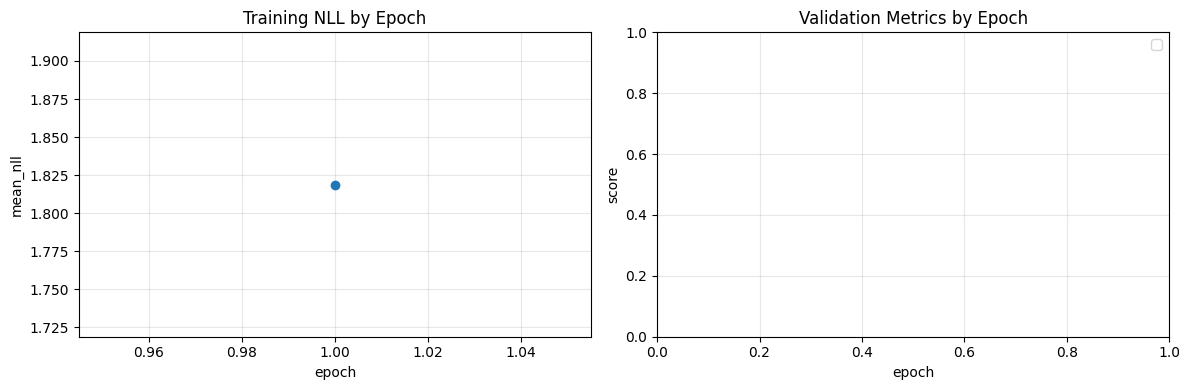

Final model checkpoint: /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run/final


In [12]:
history_df = pd.DataFrame(history)
display(history_df)
if not history_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['mean_nll'], marker='o', label='train NLL')
    axes[0].set_title('Training NLL by Epoch')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('mean_nll')
    axes[0].grid(True, alpha=0.3)
    if 'val_roc_auc' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_roc_auc'], marker='o', label='val ROC-AUC')
    if 'val_ap' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_ap'], marker='o', label='val AP')
    if 'val_score' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_score'], marker='o', label='val score')
    axes[1].set_title('Validation Metrics by Epoch')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('score')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

print('Final model checkpoint:', Path(args.save_dir) / 'final' if args.save_dir else 'not saved')


## Generation Debug

Sample one generation batch and inspect generated sequence lengths, dart diversity, and a few raw samples directly.


In [17]:
debug_num_samples = 8
debug_max_length = final_max_length
if debug_max_length is None:
    debug_max_length = default_face_generation_max_length(int(eval_info['num_reference_edges']))

print(f'debug generation max_length = {debug_max_length}')

debug_walks = sample_model_walks(
    model,
    num_samples=debug_num_samples,
    max_length=debug_max_length,
    bos_token_id=int(eval_info['bos_token_id']),
    eos_token_id=int(eval_info['eos_token_id']) if eval_info['eos_token_id'] is not None else None,
    device=device,
    batch_size=debug_num_samples,
    show_progress=True,
    progress_desc='debug sampling',
)

eos_token_id = eval_info['eos_token_id']
num_nodes = int(eval_info['num_nodes'])
lengths = np.asarray([len(seq) for seq in debug_walks], dtype=int)
has_eos = np.asarray([((eos_token_id is not None) and (int(eos_token_id) in seq)) for seq in debug_walks], dtype=bool)
vertex_token_counts = np.asarray([sum(0 <= int(tok) < num_nodes for tok in seq) for seq in debug_walks], dtype=int)

def faithful_vertices_from_sequence(seq):
    return [int(tok) for tok in seq if 0 <= int(tok) < num_nodes]

def darts_from_faithful_vertices(vertices):
    even_len = len(vertices) - (len(vertices) % 2)
    return [(int(vertices[i]), int(vertices[i + 1])) for i in range(0, even_len, 2)]

walk_vertices = [faithful_vertices_from_sequence(seq) for seq in debug_walks]
walk_darts = [darts_from_faithful_vertices(vertices) for vertices in walk_vertices]
dart_lengths = np.asarray([len(darts) for darts in walk_darts], dtype=int)
unique_dart_counts = np.asarray([len(set(darts)) for darts in walk_darts], dtype=int)

summary = pd.DataFrame([{
    'num_samples': int(debug_num_samples),
    'num_with_eos': int(has_eos.sum()),
    'frac_with_eos': float(has_eos.mean()),
    'min_length': int(lengths.min()),
    'median_length': float(np.median(lengths)),
    'mean_length': float(lengths.mean()),
    'max_length': int(lengths.max()),
    'mean_vertex_token_count': float(vertex_token_counts.mean()),
    'mean_dart_length': float(dart_lengths.mean()),
    'mean_unique_darts_per_sample': float(unique_dart_counts.mean()),
}])
display(summary)

rows = []
for idx, seq in enumerate(debug_walks[:10]):
    vertex_tokens = walk_vertices[idx]
    rows.append({
        'sample_id': idx,
        'has_eos': bool(has_eos[idx]),
        'length': int(lengths[idx]),
        'vertex_token_count': int(vertex_token_counts[idx]),
        'dart_length': int(dart_lengths[idx]),
        'num_unique_darts': int(unique_dart_counts[idx]),
        'raw_tokens_head': seq[:16],
        'vertex_tokens_head': vertex_tokens[:16],
        'tail_tokens': seq[-12:],
    })
display(pd.DataFrame(rows))

print('first 10 darts from generated sample 0:')
print(walk_darts[0][:10])


debug generation max_length = 15963


debug sampling:   0%|          | 0/127696 [00:00<?, ?tok/s]

,num_samples,num_with_eos,frac_with_eos,min_length,median_length,mean_length,max_length,mean_vertex_token_count,mean_dart_length,mean_unique_darts_per_sample
0,8,0,0.0,15963,15963.0,15963.0,15963,15962.0,7981.0,5643.0


,sample_id,has_eos,length,vertex_token_count,dart_length,num_unique_darts,raw_tokens_head,vertex_tokens_head,tail_tokens
0,0,False,15963,15962,7981,5624,"[2810, 2762, 2670, 604, 2762, 590, 604, 596, 5...","[2762, 2670, 604, 2762, 590, 604, 596, 590, 26...","[886, 2068, 671, 886, 816, 671, 2802, 816, 735..."
1,1,False,15963,15962,7981,5519,"[2810, 525, 562, 589, 525, 2547, 589, 1402, 25...","[525, 562, 589, 525, 2547, 589, 1402, 2547, 13...","[1190, 2502, 1104, 1190, 1059, 1104, 2030, 105..."
2,2,False,15963,15962,7981,5526,"[2810, 2396, 1252, 1252, 2396, 1329, 1252, 135...","[2396, 1252, 1252, 2396, 1329, 1252, 1357, 132...","[723, 188, 1645, 723, 1645, 1645, 1890, 1645, ..."
3,3,False,15963,15962,7981,5759,"[2810, 512, 1692, 1005, 512, 1023, 1005, 2191,...","[512, 1692, 1005, 512, 1023, 1005, 2191, 1023,...","[1103, 1103, 2112, 1103, 1393, 2112, 2481, 139..."
4,4,False,15963,15962,7981,5542,"[2810, 1973, 1756, 2007, 1973, 1141, 2007, 200...","[1973, 1756, 2007, 1973, 1141, 2007, 2002, 114...","[910, 764, 910, 910, 2347, 910, 539, 2347, 102..."
5,5,False,15963,15962,7981,5812,"[2810, 1292, 1284, 2052, 1292, 1409, 2052, 179...","[1292, 1284, 2052, 1292, 1409, 2052, 1795, 140...","[2344, 84, 189, 2344, 1021, 189, 84, 1021, 234..."
6,6,False,15963,15962,7981,5677,"[2810, 208, 242, 284, 208, 501, 284, 2796, 501...","[208, 242, 284, 208, 501, 284, 2796, 501, 2793...","[309, 266, 443, 309, 1890, 443, 459, 1890, 459..."
7,7,False,15963,15962,7981,5685,"[2810, 1757, 1887, 960, 1757, 988, 960, 918, 9...","[1757, 1887, 960, 1757, 988, 960, 918, 988, 96...","[445, 494, 1254, 445, 1242, 1254, 1221, 1242, ..."


first 10 darts from generated sample 0:
[(2762, 2670), (604, 2762), (590, 604), (596, 590), (2670, 596), (604, 2670), (590, 604), (602, 590), (590, 602), (2429, 590)]


## Final Evaluation

Generate walks from the trained model, reconstruct a graph, and compare link prediction and graph statistics against the true CoraML LCC.


final generation max_length = 15963


final sampling graph 1/1:   0%|          | 0/510784 [00:00<?, ?tok/s]

,graph_id,val_roc_auc,val_ap,test_roc_auc,test_ap,edge_overlap
0,0,0.686897,0.686219,0.674182,0.672156,0.447563


,metric,true_coraml,generated_mean,abs_diff
0,max_degree,246.000000,215.000000,31.000000
1,assortativity,-0.076592,-0.064630,0.011962
2,triangle_count,5247.000000,3120.000000,2127.000000
3,power_law_exp,1.500883,1.523815,0.022931
4,clustering_coeff,0.114298,0.058205,0.056093
5,characteristic_path_len,5.271418,4.111555,1.159863
6,inter_community_density,0.000526,0.001086,0.000560
7,intra_community_density,0.009280,0.006564,0.002716


,epoch,mean_nll,perplexity,generated_max_degree,generated_assortativity,generated_triangle_count,generated_power_law_exp,generated_clustering_coeff,generated_characteristic_path_len,generated_inter_community_density,generated_intra_community_density,edge_overlap
0,1.0,1.818802,6.164472,248.0,-0.063331,4069.0,1.515239,0.069006,4.055151,0.000962,0.007165,0.528129


,epoch,generated_max_degree,generated_assortativity,generated_triangle_count,generated_power_law_exp,generated_clustering_coeff,generated_characteristic_path_len,generated_inter_community_density,generated_intra_community_density
0,1.0,248.0,-0.063331,4069.0,1.515239,0.069006,4.055151,0.000962,0.007165


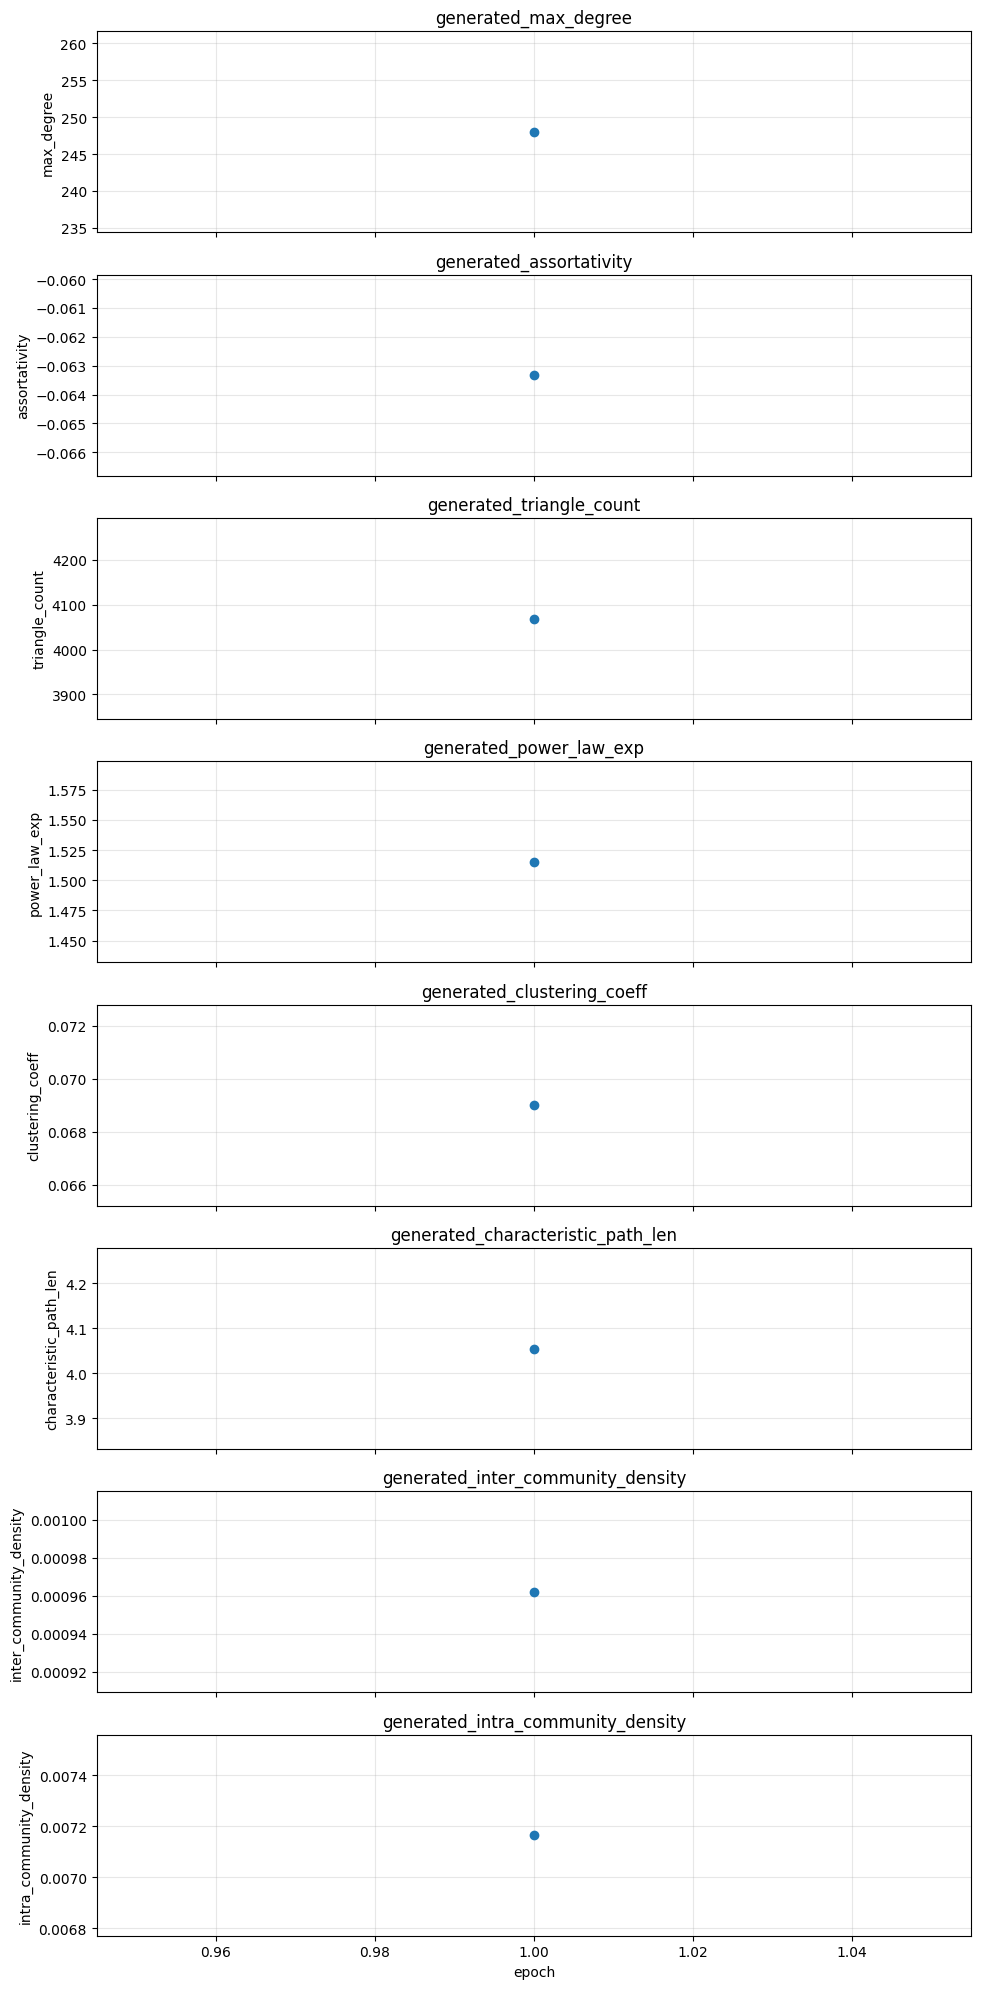

In [15]:
reference_adj = eval_info['reference_adj']
reference_labels = eval_info['reference_labels']
num_nodes = int(eval_info['num_nodes'])
num_reference_edges = int(eval_info['num_reference_edges'])
if final_max_length is None:
    final_max_length = train_mod.default_face_generation_max_length(num_reference_edges)
print(f'final generation max_length = {final_max_length}')
lp_split = eval_info['link_prediction_split']
if lp_split is None:
    lp_split = connected_link_prediction_split(
        reference_adj,
        val_fraction=args.val_fraction,
        test_fraction=args.test_fraction,
        seed=args.split_seed,
    )

reference_stats = compute_graph_statistics(reference_adj, labels=reference_labels)

generated_results = []
generated_stats_rows = []

for graph_idx in range(num_generated_graphs):
    walks = sample_model_walks(
        model,
        num_samples=final_generated_walks,
        max_length=final_max_length,
        bos_token_id=int(eval_info['bos_token_id']),
        eos_token_id=int(eval_info['eos_token_id']) if eval_info['eos_token_id'] is not None else None,
        device=device,
        batch_size=generation_batch_size,
        show_progress=True,
        progress_desc=f'final sampling graph {graph_idx + 1}/{num_generated_graphs}',
    )

    A_hat, S = reconstruct_graph_from_generated_walks(
        walks,
        num_nodes=num_nodes,
        target_num_edges=num_reference_edges,
        seed=reconstruction_seed + graph_idx,
    )

    val_scores = link_prediction_scores_from_walks(
        walks,
        num_nodes=num_nodes,
        positive_edges=lp_split['val_edges'],
        negative_edges=lp_split['val_non_edges'],
    )
    test_scores = link_prediction_scores_from_walks(
        walks,
        num_nodes=num_nodes,
        positive_edges=lp_split['test_edges'],
        negative_edges=lp_split['test_non_edges'],
    )
    graph_stats = compute_graph_statistics(A_hat, labels=reference_labels)
    overlap = edge_overlap_ratio(A_hat, reference_adj)

    generated_results.append({
        'graph_id': graph_idx,
        'val_roc_auc': float(val_scores['roc_auc']),
        'val_ap': float(val_scores['average_precision']),
        'test_roc_auc': float(test_scores['roc_auc']),
        'test_ap': float(test_scores['average_precision']),
        'edge_overlap': float(overlap),
    })
    generated_stats_rows.append(graph_stats)

lp_table = pd.DataFrame(generated_results)
display(lp_table)

metric_names = list(reference_stats.keys())
stats_table = pd.DataFrame([
    {
        'metric': metric,
        'true_coraml': float(reference_stats[metric]),
        'generated_mean': float(np.nanmean([row[metric] for row in generated_stats_rows])),
        'abs_diff': abs(
            float(np.nanmean([row[metric] for row in generated_stats_rows]))
            - float(reference_stats[metric])
        ),
    }
    for metric in metric_names
])
display(stats_table)

if history:
    history_df = pd.DataFrame(history)
    display(history_df)

    generated_stat_cols = [
        col for col in history_df.columns
        if col.startswith('generated_')
    ]
    if generated_stat_cols:
        generated_stats_history = history_df[['epoch', *generated_stat_cols]].copy()
        display(generated_stats_history)

        plot_cols = [
            col for col in generated_stat_cols
            if pd.api.types.is_numeric_dtype(history_df[col])
        ]
        if plot_cols:
            fig, axes = plt.subplots(
                len(plot_cols),
                1,
                figsize=(10, max(3, 2.5 * len(plot_cols))),
                sharex=True,
            )
            axes = np.atleast_1d(axes)
            for ax, col in zip(axes, plot_cols):
                ax.plot(history_df['epoch'], history_df[col], marker='o')
                ax.set_title(col)
                ax.set_ylabel(col.replace('generated_', ''))
                ax.grid(alpha=0.3)
            axes[-1].set_xlabel('epoch')
            plt.tight_layout()
            plt.show()
